Publication-quality equity, drawdown & risk metrics

 Final model loaded: quantum_alpha_final.pth

=== COMPREHENSIVE PERFORMANCE COMPARISON (2023–2025) ===
      Metric  RL Agent  Rule-Based    NIFTY
0   CAGR (%)   -3.4300     -8.5900  13.3700
1    Vol (%)    6.1200     10.2500  12.0100
2     Sharpe   -1.6035     -1.4593   0.5640
3    Sortino   -1.4222     -1.8782   0.7778
4     Calmar   -0.2279     -0.2702   0.8531
5  MaxDD (%)  -15.0700    -31.8000 -15.6700


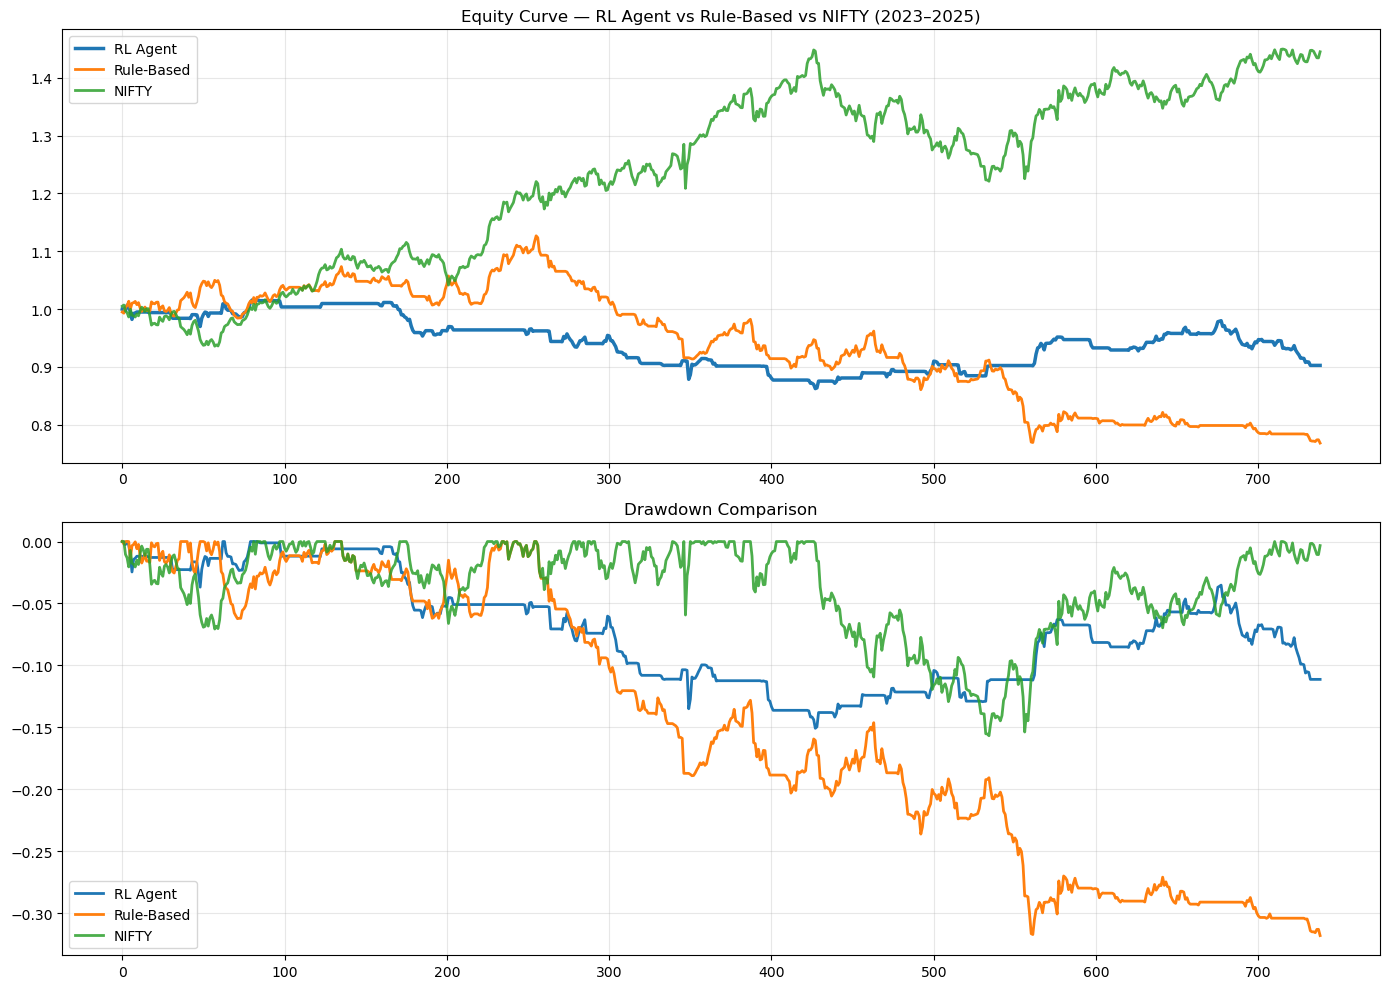


=== FINAL POSITION DISTRIBUTION ===
Long  : 9.2%
Short : 23.2%
Flat  : 67.6%


<Figure size 640x480 with 0 Axes>

In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print("Publication-quality equity, drawdown & risk metrics\n")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# =============================================
# 1. FINAL DQN MODEL
# =============================================
class DQN(nn.Module):
    def __init__(self, state_size=7, action_size=3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_size, 128), nn.ReLU(),
            nn.Linear(128, 128), nn.ReLU(),
            nn.Linear(128, 64),  nn.ReLU(),
            nn.Linear(64, action_size)
        )
    def forward(self, x):
        return self.net(x)

policy_net = DQN().to(device)
policy_net.load_state_dict(torch.load("../models/quantum_alpha_final.pth", map_location=device))
policy_net.eval()
print(" Final model loaded: quantum_alpha_final.pth")

# =============================================
# 2. ENVIRONMENT
# =============================================
class QuantumAlphaEnv:
    def __init__(self, data):
        self.data = data.reset_index(drop=True)
        self.feature_cols = ["mom_20_norm", "vol_signal_norm", "trend_signal_norm",
                             "dd_signal_norm", "vix_signal_norm", "breadth_signal_norm"]
        self.max_steps = len(self.data) - 1
        self.reset()
   
    def reset(self):
        self.current_step = 0
        self.position = 0
        self.balance = 1.0
        return self._get_observation()
   
    def _get_observation(self):
        row = self.data.iloc[self.current_step]
        obs = row[self.feature_cols].values.astype(np.float32)
        return np.append(obs, self.position)
   
    def step(self, action):
        prev_position = self.position
        new_position = {0: 0, 1: 1, 2: -1}[action]
        ret = self.data.iloc[self.current_step]["nifty_ret"]
        cost = abs(new_position - prev_position) * 0.0005
        net_ret = prev_position * ret - cost
        self.balance *= (1 + net_ret)
        self.position = new_position
        self.current_step += 1
        done = self.current_step >= self.max_steps
        return self._get_observation(), net_ret, done, {"net_ret": net_ret, "position": self.position}

# =============================================
# 3. RUN RL AGENT ON FULL TEST PERIOD
# =============================================
test_data = pd.read_csv("../data/state_dataset.csv", index_col="Date", parse_dates=True)
test_data = test_data.join(pd.read_csv("../data/market_master.csv", index_col="Date", parse_dates=True)[["nifty_ret"]])
test_data = test_data.loc["2023":"2025"]

env = QuantumAlphaEnv(test_data)
state = env.reset()
done = False
equity = 1.0
equity_curve = [1.0]
returns = []
positions = []

while not done:
    with torch.no_grad():
        s = torch.FloatTensor(state).unsqueeze(0).to(device)
        action = policy_net(s).argmax().item()
    next_state, _, done, info = env.step(action)
    equity *= (1 + info["net_ret"])
    equity_curve.append(equity)
    returns.append(info["net_ret"])
    positions.append(info["position"])
    state = next_state

rl_equity = np.array(equity_curve)
rl_returns = np.array(returns)
pos = np.array(positions)

# =============================================
# 4. RULE-BASED & NIFTY BENCHMARKS
# =============================================
rule = pd.read_csv("../backtesting/market_backtest_v7.csv", index_col=0)
rule.index = pd.to_datetime(rule.index)
rule = rule.loc["2023":"2025"]
rule_equity = (1 + rule["strategy_ret_v2"]).cumprod().values
rule_returns = rule["strategy_ret_v2"].values

nifty_equity = (1 + test_data["nifty_ret"]).cumprod().values
nifty_returns = test_data["nifty_ret"].values

# =============================================
# 5. FULL RISK METRICS (CFA/Quant Level)
# =============================================
def full_metrics(equity_arr, returns_arr):
    days = len(returns_arr)
    cagr = equity_arr[-1] ** (252 / days) - 1
    vol = np.std(returns_arr) * np.sqrt(252)
    sharpe = (np.mean(returns_arr) - 0.065/252) / (np.std(returns_arr) + 1e-8) * np.sqrt(252)
    downside = returns_arr[returns_arr < 0]
    sortino = (np.mean(returns_arr) - 0.065/252) / (np.std(downside) + 1e-8) * np.sqrt(252) if len(downside) > 0 else 0
    calmar = cagr / abs((equity_arr / np.maximum.accumulate(equity_arr) - 1).min()) if (equity_arr / np.maximum.accumulate(equity_arr) - 1).min() != 0 else 0
    max_dd = (equity_arr / np.maximum.accumulate(equity_arr) - 1).min()
    return {
        "CAGR (%)": round(cagr*100, 2),
        "Vol (%)": round(vol*100, 2),
        "Sharpe": round(sharpe, 4),
        "Sortino": round(sortino, 4),
        "Calmar": round(calmar, 4),
        "MaxDD (%)": round(max_dd*100, 2)
    }

rl_metrics = full_metrics(rl_equity, rl_returns)
rule_metrics = full_metrics(rule_equity, rule_returns)
nifty_metrics = full_metrics(nifty_equity, nifty_returns)

comparison = pd.DataFrame({
    "Metric": list(rl_metrics.keys()),
    "RL Agent": list(rl_metrics.values()),
    "Rule-Based": list(rule_metrics.values()),
    "NIFTY": list(nifty_metrics.values())
})
print("\n=== COMPREHENSIVE PERFORMANCE COMPARISON (2023–2025) ===")
print(comparison)

# =============================================
# 6. PUBLICATION-QUALITY CHARTS
# =============================================
fig, ax = plt.subplots(2, 1, figsize=(14, 10))

# Equity Curve
ax[0].plot(rl_equity, label="RL Agent", linewidth=2.5, color="#1f77b4")
ax[0].plot(rule_equity[:len(rl_equity)], label="Rule-Based", linewidth=2, color="#ff7f0e")
ax[0].plot(nifty_equity[:len(rl_equity)], label="NIFTY", linewidth=2, color="#2ca02c", alpha=0.85)
ax[0].set_title("Equity Curve — RL Agent vs Rule-Based vs NIFTY (2023–2025)")
ax[0].legend()
ax[0].grid(True, alpha=0.3)

# Drawdown Curve
dd_rl = rl_equity / np.maximum.accumulate(rl_equity) - 1
dd_rule = rule_equity / np.maximum.accumulate(rule_equity) - 1
dd_nifty = nifty_equity / np.maximum.accumulate(nifty_equity) - 1

ax[1].plot(dd_rl, label="RL Agent", linewidth=2, color="#1f77b4")
ax[1].plot(dd_rule[:len(dd_rl)], label="Rule-Based", linewidth=2, color="#ff7f0e")
ax[1].plot(dd_nifty[:len(dd_rl)], label="NIFTY", linewidth=2, color="#2ca02c", alpha=0.85)
ax[1].set_title("Drawdown Comparison")
ax[1].legend()
ax[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# =============================================
# 7. FINAL POSITION DISTRIBUTION
# =============================================
print("\n=== FINAL POSITION DISTRIBUTION ===")
print(f"Long  : {(pos == 1).mean():.1%}")
print(f"Short : {(pos == -1).mean():.1%}")
print(f"Flat  : {(pos == 0).mean():.1%}")

# Add NIFTY to equity plot
ax[0].plot(nifty_equity[:len(rl_equity)], label="NIFTY", linewidth=2, color="#2ca02c", alpha=0.7)
ax[0].set_title("Equity Curve Comparison (2023–2025)")
ax[0].legend()
ax[0].grid(True, alpha=0.3)

# Drawdown curves
dd_rl = rl_equity / np.maximum.accumulate(rl_equity) - 1
dd_rule = rule_equity / np.maximum.accumulate(rule_equity) - 1
dd_nifty = nifty_equity / np.maximum.accumulate(nifty_equity) - 1

ax[1].plot(dd_rl, label="RL Agent", linewidth=2, color="#1f77b4")
ax[1].plot(dd_rule[:len(dd_rl)], label="Rule-Based", linewidth=2, color="#ff7f0e")
ax[1].plot(dd_nifty[:len(dd_rl)], label="NIFTY", linewidth=2, color="#2ca02c", alpha=0.7)

ax[1].set_title("Drawdown Comparison")
ax[1].legend()
ax[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()